# Environmental Risk & Justice: Mapping Population Exposure to Industrial Airborne Pollution in Kalamazoo County, Michigan

## 1 Objectives

This project conducts a geospatial assessment of environmental risk and potential human exposure to industrial airborne emissions in Kalamazoo County, Michigan. Using data from the United States Environmental Protection Agency Toxic Release Inventory (TRI) alongside population and land surface datasets, the analysis identifies spatial patterns of potential exposure. The study integrates multiple spatial layers to estimate both residential exposure and mobility-based exposure through transportation networks.

# 2. Initial Assessment & Level of Effort (LOE)

This project involves the integration and analysis of multiple geospatial datasets representing environmental hazards and human presence. The workflow includes:

Data acquisition from authoritative sources (EPA, GEE, ESA, OSM)
Preprocessing and harmonization of spatial datasets
Aggregation and transformation of industrial emission data
Spatial modeling of exposure using buffer and overlay techniques
Raster–vector integration for population estimation
Network-based analysis of exposure along transportation routes
Visualization and interpretation of results through maps and charts

This project is requiring proficiency in GIS (ArcGIS Pro), Python-based geospatial analysis (GeoPandas, Pandas, matplot, raster processing), and cloud-based data access (Google Earth Engine). Additional effort is required for data cleaning, coordinate system alignment, and integration across different spatial formats.

## 3. Datasets Used

The following datasets were used to support the environmental risk and exposure analysis:

 **3.1 Toxic Release Inventory (TRI) – 2020**

   Source: [United States Environmental Protection Agency](https://www.epa.gov/)

   - Point dataset representing industrial facilities reporting chemical releases
   - Attributes include fugitive air emissions, stack air emissions, and total airborne releases
   - Data were preprocessed and aggregated at the facility level to represent total annual emissions
   - Serves as the primary environmental hazard (risk) layer

**3.2 WorldPop Population Data – 2020 (Google Earth Engine)**

   Source: [WorldPop Project](https://hub.worldpop.org/) via [Google Earth Engine](https://earthengine.google.com/)

   - Raster dataset representing gridded population distribution
   - Used to estimate the number of people residing within exposure zones
   - Provides a spatially continuous representation of population density

**3.3 ESA WorldCover Land Cover – 2020**

   Source: [European Space Agency](https://www.esa.int/)

   - 10-meter resolution global land cover dataset
   - Used to characterize land surface composition within exposure zones
   - Supports interpretation of exposure in relation to built-up areas, vegetation, and other land classes


**3.4 Road Network Data (OpenStreetMap / GEE)**

   Source: [OpenStreetMap](https://www.openstreetmap.org/)

   - Vector dataset representing major transportation routes
   - Used to assess commuter exposure by identifying road segments intersecting TRI buffer zones
   
 **3.5 Kalamazoo County Boundary**
 
   Source: https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.2020.html#list-tab-790442341 

   - Polygon dataset displaying Michigan's county & defining the study area
   - Used for spatial clipping, masking, and analysis extent control
   




## 4. Project Workflow

- Preprocessing and cleaning of the CSV data in ArcGIS pro
- Importing TRI dataset in the notebook (as a shapefile) 
- Aggregate emissions at facility level (fugitive + stack air)
- Convert dataset to GeoDataFrame format
- Load and prepare population (WorldPop), land cover (ESA), and road network datasets
- Align coordinate reference systems and clip to Kalamazoo County boundary
- Map and visualize TRI facility distribution
- Create buffer zones around TRI facilities
- Overlay buffers with population raster to estimate exposed population
- Analyze land cover composition within exposure zones
- Intersect buffers with road network to identify exposed road segments



## 5. Data Preparation, Exploration and Visualization

### 5.1 TRI Data Preprocessing

For this project, Toxic Release Inventory (TRI) data from the United States Environmental Protection Agency was used to represent industrial airborne emissions. The year 2020 was selected to ensure temporal consistency with other datasets used in the analysis, including population (WorldPop) and land cover (ESA WorldCover), both of which are also available for the same year.

The TRI dataset was downloaded in CSV format, which includes geographic coordinates (latitude and longitude) for facilities across the United States. These coordinates allowed the data to be imported into ArcGIS Pro as point features using the “Add XY Data” tool for preprocessing and data cleaning. Because TRI data are self-reported by facilities, each facility may contain multiple records corresponding to different chemicals and release types throughout the year.

Specifically, airborne emissions are categorized into:

Fugitive air emissions (uncontrolled releases such as leaks or evaporation)

Stack air emissions (controlled releases through chimneys or vents)

Since these emissions are reported separately for multiple chemicals and time periods, a single facility may appear multiple times in the dataset. To address this, a preprocessing step was conducted in ArcGIS Pro to aggregate emissions at the facility level. This was done by summing:

Fugitive air emissions

Stack air emissions

Total air emissions (fugitive + stack)

This aggregation ensured that each facility is represented as a single point with total annual airborne emissions, simplifying subsequent spatial analysis.
It is important to note that different chemicals have varying levels of toxicity and environmental impact. However, in this project, all airborne emissions were treated uniformly as a generalized indicator of industrial air pollution exposure, without weighting emissions by toxicity or health risk. While this approach simplifies the analysis, it introduces a limitation that should be considered when interpreting results.

After preprocessing, the cleaned TRI dataset was exported and imported into the VS Code Python environment for further analysis.

The analysis begins with an exploratory assessment of the spatial and attribute characteristics of the Toxic Release Inventory (TRI) dataset. This step is essential for understanding the distribution and magnitude of industrial emissions across the study area.

Key exploratory tasks include:

Mapping the spatial distribution of TRI facility locations within Kalamazoo County
Examining attribute data related to fugitive air emissions, stack air emissions, and total airborne releases
Identifying facilities with relatively high emission values to understand potential hotspots of industrial activity

This exploratory phase provides a foundational understanding of the spatial distribution of environmental hazards and informs subsequent steps in exposure modeling. Visualization outputs from this stage support the identification of areas where elevated emissions may contribute to increased environmental risk.

### 5.2 TRI Data Exploration

In [2]:
import geopandas as gpd
gdf = gpd.read_file('../data/processed/TRI_Kalamazoo_2020.shp')
print(gdf.shape)
print(gdf.head(23))   
print(gdf.columns)  

(23, 23)
    YEAR            TRIFD        FRS_ID  \
0   2020  49001THPJH7171P  1.100710e+11   
1   2020  4900WHVLND2722N  1.100040e+11   
2   2020  4904WKSRLM525KA  1.100400e+11   
3   2020  49008RCHRD4481C  1.100230e+11   
4   2020  4900WDMPLX2625E  1.100040e+11   
5   2020  4900WMCHGN2GLEN  1.100020e+11   
6   2020  49007JMSRV243EA  1.100640e+11   
7   2020  49003MRCNC2715M  1.100000e+11   
8   2020  49003HMPHRKILGO  1.100010e+11   
9   2020  49001BWRSM6565S  1.100000e+11   
10  2020  4900WCYTCN3115M  1.100580e+11   
11  2020  49097KPCNC145NL  1.100250e+11   
12  2020  4902WFMCRP1716V  1.100020e+11   
13  2020  4900WCHMST5933W  1.100700e+11   
14  2020  4908WPRKRH8676E  1.100020e+11   
15  2020  49004WLLSL5575N  1.100010e+11   
16  2020  49007KLSCN3713W  1.100000e+11   
17  2020  49001DRMTL2100F  1.100000e+11   
18  2020  4901WFRTCS25126  1.100420e+11   
19  2020  4900WSTRYK41EMI  1.100040e+11   
20  2020  49007ZNSYS2204R  1.100000e+11   
21  2020  4900WCHMST5933W  1.100700e+11   
22

In [ ]:
# columns list
list(gdf.columns)

['YEAR',
 'TRIFD',
 'FRS_ID',
 'FACILITY_N',
 'PARENT_CO_',
 'F5__STREET',
 'CITY',
 'COUNTY',
 'ST',
 'ZIP',
 'LATITUDE',
 'LONGITUDE',
 'PARENT_CO1',
 'STANDARD_P',
 'INDUSTRY_S',
 'PRIMARY_NA',
 'SUM_TOTAL_',
 'SUM_FUGITI',
 'SUM_STACK_',
 'CLEAN_AIR_',
 'CARCINOGEN',
 'UNIT_OF_ME',
 'geometry']

In [ ]:
# Checking the columns of interest
gdf[['FACILITY_N','STANDARD_P', 'TRIFD', 'LATITUDE', 'LONGITUDE', 'SUM_TOTAL_', 'SUM_FUGITI', 'SUM_STACK_']]

,FACILITY_N,STANDARD_P,TRIFD,LATITUDE,LONGITUDE,SUM_TOTAL_,SUM_FUGITI,SUM_STACK_
0,PHARMACIA & UPJOHN CO LLC A SUBSIDIARY OF PFIZ...,PFIZER INC,49001THPJH7171P,42.211331,-85.559880,258084.000,5256.000,55418.000
1,HAVILAND PRODUCTS CO,HAVILAND ENTERPRISES INC,4900WHVLND2722N,42.318530,-85.583848,1186.488,8.200,712.000
2,KAISER ALUMINUM FABRICATED PRODUCTS LLC,KAISER ALUMINUM FABRICATED PRODUCTS LLC,4904WKSRLM525KA,42.254883,-85.523367,3.066,0.000,1.430
3,RICHARD-ALLAN SCIENTIFIC,NEW ERIE,49008RCHRD4481C,42.256687,-85.638651,1031.370,0.000,904.210
4,DIMPLEX THERMAL SOLUTIONS,NA,4900WDMPLX2625E,42.264782,-85.550463,10.000,5.000,5.000
5,MICHIGAN PAVING & MATERIALS CO - KALAMAZOO ASP...,CRH AMERICAS INC,4900WMCHGN2GLEN,42.271198,-85.548816,1.055,0.685,0.370
6,GRAPHIC PACKAGING INTERNATIONAL INC,GRAPHIC PACKAGING HOLDING CO,49007JMSRV243EA,42.305583,-85.578876,193.000,0.000,4.000
7,ALLNEX USA INC,ALLNEX USA INC,49003MRCNC2715M,42.266915,-85.545706,167566.010,3242.700,5363.700
8,HUMPHREY PRODUCTS CO,HUMPHREY PRODUCTS CO,49003HMPHRKILGO,42.244901,-85.529387,266.500,5.000,250.000
9,BOWERS MANUFACTURING,NA,49001BWRSM6565S,42.222307,-85.540444,1405.468,18.396,1377.072


In [5]:
gdf[['SUM_TOTAL_', 'SUM_FUGITI', 'SUM_STACK_']].sum()

SUM_TOTAL_    455748.947
SUM_FUGITI     10236.091
SUM_STACK_     64390.782
dtype: float64

In [6]:

## Rename columns for better readability
gdf = gdf.rename(columns={
    'FACILITY_N': 'FACILITY',
    'STANDARD_P': 'PARENT_COMPANY',
    'SUM_TOTAL_': 'TOTAL_RELEASES',
    'SUM_FUGITI': 'FUGITIVE_AIR',
    'SUM_STACK_': 'STACK_AIR'
})

In [8]:
## creating new column for risk score based on FUGITIVE_AIR releases
gdf['RISK_SCORE'] = gdf['FUGITIVE_AIR']

In [9]:
## Display top 10 facilities by risk score
gdf.sort_values(by='RISK_SCORE', ascending=False)[
    ['FACILITY', 'RISK_SCORE']
].head(10)

,FACILITY,RISK_SCORE
0,PHARMACIA & UPJOHN CO LLC A SUBSIDIARY OF PFIZ...,5256.000
7,ALLNEX USA INC,3242.700
10,CYTEC ENGINEERED MATERIALS,1548.000
17,FLOWSERVE CORP,147.110
9,BOWERS MANUFACTURING,18.396
1,HAVILAND PRODUCTS CO,8.200
4,DIMPLEX THERMAL SOLUTIONS,5.000
11,KEPCO INC,5.000
8,HUMPHREY PRODUCTS CO,5.000
5,MICHIGAN PAVING & MATERIALS CO - KALAMAZOO ASP...,0.685


<Axes: >

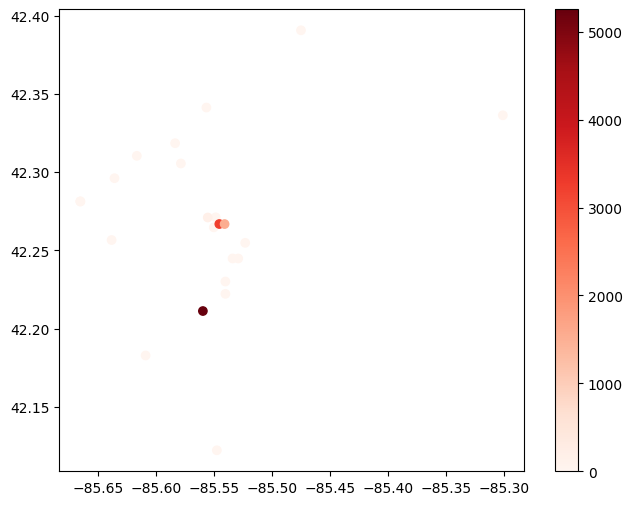

In [10]:
## map visualization of facilities colored by risk score
import matplotlib.pyplot as plt
gdf.plot(
    column='RISK_SCORE',
    cmap='Reds',
    legend=True,
    figsize=(8, 6)
)

### 5.3 Data Visualiztion & Exploratory maps

In this section I am going to add the necessary data to the notebook and create some exploratory maps


### 5.3.1 Adding Michigasn Counties Boundary from GEE

In [11]:
import ee
ee.Authenticate()

/home/aman/assignments/kalamazoo-environmental-risk/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


True

In [12]:
## importing geemap and initializing Earth Engine

import geemap
import geopandas as gpd
ee.Initialize(project='geo5830')


In [13]:
## Loading US Counties in GEE and filter for Kalamazoo County
counties = ee.FeatureCollection('TIGER/2018/Counties') 
## filtering to michigan counties
mi_counties = counties.filter(ee.Filter.eq('STATEFP', '26'))
## Selecting kalamazoo county
kalamazoo = mi_counties.filter(ee.Filter.eq('NAME', 'Kalamazoo'))
## selecting as ROI
roi = kalamazoo.geometry()
## visualizing the county boundary
Map = geemap.Map(basemap='CartoDB.Positron')
Map.centerObject(mi_counties, 6)

Map.addLayer(mi_counties, {'color': 'blue'}, 'Michigan Counties')
Map.addLayer(kalamazoo, {'color': 'red'}, 'Kalamazoo County')

Map

Map(center=[44.83697198905648, -85.6641787996602], controls=(WidgetControl(options=['position', 'transparent_b…


### 5.3.2 Loading Population Data from GEE

In [14]:
# Loading population density data from WorldPop for 2020

pop = ee.ImageCollection('WorldPop/GP/100m/pop') \
        .filterDate('2020-01-01', '2020-12-31') \
        .first()

In [15]:
## loading 2020 population data for USA from WorldPop and clipping to Kalamazoo County
pop = (
    ee.ImageCollection('WorldPop/GP/100m/pop')
    .filter(ee.Filter.eq('country', 'USA'))
    .filter(ee.Filter.eq('year', 2020))
    .first()
    .select('population')
)
pop_kzoo = pop.clip(roi)

In [16]:
## Visualization of population density in Kalamazoo County
Map = geemap.Map(basemap='CartoDB.Positron')
Map.centerObject(kalamazoo, 10)

pop_vis = {
    'min': 0,
    'max': 30,  
    'palette': ['white', 'yellow', 'orange', 'red']} 

Map.addLayer(pop_kzoo, pop_vis, 'Population')

Map.addLayer(
    kalamazoo.style(**{
        'color': 'Black',
        'fillColor': '00000000',
        'width': 2
    }),
    {},
    'Kalamazoo County'
)

Map

Map(center=[42.245373214188064, -85.53118107546229], controls=(WidgetControl(options=['position', 'transparent…


### 5.3.3 Adding TRI Facilities to the Map

In [17]:
## Converting GeoDataFrame to GEE
tri_ee = geemap.geopandas_to_ee(gdf)

# Map visualization of TRI facilities and population density in Kalamazoo County
Map = geemap.Map(basemap='CartoDB.Positron')
Map.centerObject(kalamazoo, 10)



Map_tri = geemap.Map(basemap='CartoDB.Positron')
Map_tri.centerObject(kalamazoo, 10)

Map_tri.addLayer(pop_kzoo, pop_vis, 'WorldPop Population 2020')

pop_vis = {
    'min': 0,
    'max': 30,
    'palette': ['white', 'yellow', 'orange', 'red', 'darkred']
}

Map_tri.addLayer(
    tri_ee.style(**{
        'color': 'blue',
        'pointSize': 2,
        'width': 1
    }),
    {},
    'TRI Facilities 2020'
)

Map_tri.addLayer(
    kalamazoo.style(**{
        'color': 'black',
        'fillColor': '00000000',
        'width': 3
    }),
    {},
    'Kalamazoo County Boundary'
)

Map_tri

Map(center=[42.245373214188064, -85.53118107546229], controls=(WidgetControl(options=['position', 'transparent…

The spatial distribution of TRI facilities indicates a concentration in populated are around Milwood Area. This means that industrial emissions are not evenly distributed across the county. This pattern is critical for understanding localized exposure risk.

### 5.3.4 Adding Landcover Data to the Map

In [19]:
## Adding landcover data from ESA WorldCover to visualize land cover types in Kalamazoo County

worldcover = ee.Image('ESA/WorldCover/v100/2020')
worldcover_kzoo = worldcover.clip(roi)  
lc_vis = {
    'min': 10,
    'max': 100,
    'palette': [
        '006400',  # Tree cover
        'ffbb22',  # Shrubland
        'ffff4c',  # Grassland
        'f096ff',  # Cropland
        'fa0000',  # Built-up
        'b4b4b4',  # Bare / sparse vegetation
        'f0f0f0',  # Snow and ice
        '0064c8',  # Permanent water bodies
        '0096a0',  # Herbaceous wetland
        '00cf75'   # Mangroves
    ]
}
Map_lc = geemap.Map(basemap='CartoDB.Positron')
Map_lc.centerObject(kalamazoo, 10)

Map_lc.addLayer(worldcover_kzoo, lc_vis, 'ESA Land Cover 2020')

Map_lc.addLayer(
    kalamazoo.style(**{
        'color': 'black',
        'fillColor': '00000000',
        'width': 3
    }),
    {},
    'Kalamazoo County Boundary'
)

Map_lc

Map(center=[42.245373214188064, -85.53118107546229], controls=(WidgetControl(options=['position', 'transparent…

### 5.3.5 Adding Road Networks to the Map

In [20]:
# adding road network data from OpenStreetMap to visualize major roads in Kalamazoo County
import osmnx as ox
import geopandas as gpd

kzoo_gdf = geemap.ee_to_gdf(kalamazoo)
kzoo_gdf = kzoo_gdf.to_crs(epsg=4326)

kzoo_geom = kzoo_gdf.geometry.iloc[0]

roads_graph = ox.graph_from_polygon(
    kzoo_geom,
    network_type='drive'
)

roads = ox.graph_to_gdfs(
    roads_graph,
    nodes=False,
    edges=True
)

major_road_types = [
    'motorway',
    'trunk',
    'primary',
    'secondary'
]

roads['highway_str'] = roads['highway'].astype(str)

major_roads = roads[
    roads['highway_str'].str.contains(
        '|'.join(major_road_types),
        case=False,
        na=False
    )
].copy()


roads_ee = geemap.geopandas_to_ee(major_roads)

Map_roads = geemap.Map(basemap='CartoDB.Positron')
Map_roads.centerObject(kalamazoo, 10)

Map_roads.addLayer(
    roads_ee.style(**{
        'color': 'gray',
        'width': 1.5
    }),
    {},
    'Major Roads'
)

Map_roads.addLayer(
    kalamazoo.style(**{
        'color': 'darkblue',
        'fillColor': '00000000',
        'width': 3
    }),
    {},
    'Kalamazoo County Boundary'
)

Map_roads

Map(center=[42.245373214188064, -85.53118107546229], controls=(WidgetControl(options=['position', 'transparent…



### 5.3.6 Creating a Combined Map of the Added Data 

In [21]:
# Createing combined map
Map_combined = geemap.Map(basemap='CartoDB.Positron')
Map_combined.centerObject(kalamazoo, 10)

# 1. population density
Map_combined.addLayer(pop_kzoo, pop_vis, 'Population Density')  

pop_vis = {
    'min': 0,
    'max': 30,  
    'palette': ['white', 'yellow', 'orange', 'red']}

# 2. ESA Land Cover (softened)

lc_vis = {
    'min': 10,
    'max': 100,
    'palette': [
        '#d9f0d3',  # Trees
        '#addd8e',  # Shrubland
        '#ffffcc',  # Grassland
        '#fdae61',  # Cropland
        '#f03b20',  # Built-up (strong)
        '#cccccc',  # Bare
        '#f7f7f7',  # Snow
        '#74add1',  # Water
        '#abd9e9',  # Wetlands
        '#c7e9b4'
    ]
}

Map_combined.addLayer(
    worldcover_kzoo,
    lc_vis,
    'ESA Land Cover 2020'
)


# 3. Roads

roads_ee = geemap.geopandas_to_ee(major_roads)

Map_combined.addLayer(
    roads_ee.style(**{
        'color': '#555555',
        'width': 1
    }),
    {},
    'Road Network'
)


# 4. TRI Facilities 

tri_ee = geemap.geopandas_to_ee(gdf)

Map_combined.addLayer(
    tri_ee.style(**{
        'color': 'darkblue', 
        'pointSize': 3,
        'width': 1
    }),
    {},
    'TRI Facilities 2020'
)
 

# 5. Kalamazoo Boundary
Map_combined.addLayer(
    kalamazoo.style(**{
        'color': "#01060e",
        'fillColor': '00000000',
        'width': 2
    }),
    {},
    'Kalamazoo County Boundary'
)

# Display map
Map_combined

Map(center=[42.245373214188064, -85.53118107546229], controls=(WidgetControl(options=['position', 'transparent…

The combined map illustrate that the distribution of TRI facilities shows a clear concentration in the urban and industrial core of Kalamazoo County with the highest potential exposure occurring in areas where:

Industrial facilities are clustered

Population density is relatively high

Transportation networks are heavily utilized





## 6 Exposure Analysis

### 6.1 TRI Facilities and Population Exposure

This analysis evaluates population exposure to airborne emissions from TRI facilities using distance-based proximity analysis.

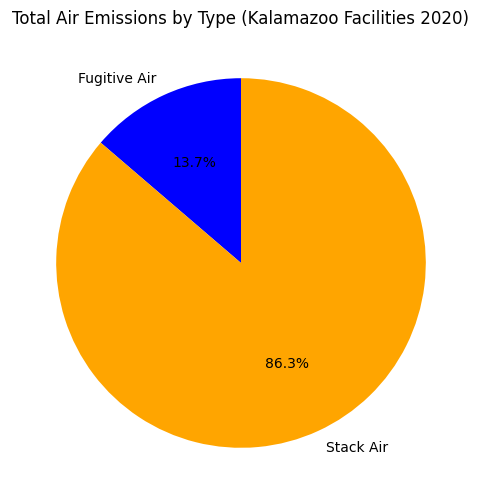

In [22]:
# Creating a pie chart to show the proportion of fugitive vs stack air emissions

import matplotlib.pyplot as plt

# Sum values
fugitive_total = gdf['FUGITIVE_AIR'].sum()
stack_total = gdf['STACK_AIR'].sum()

# Plot
plt.figure(figsize=(6,6))
plt.pie(
    [fugitive_total, stack_total],
    labels=['Fugitive Air', 'Stack Air'],
    autopct='%1.1f%%',
    colors=['blue', 'orange'],
    startangle=90
)

plt.title('Total Air Emissions by Type (Kalamazoo Facilities 2020)')
plt.show()

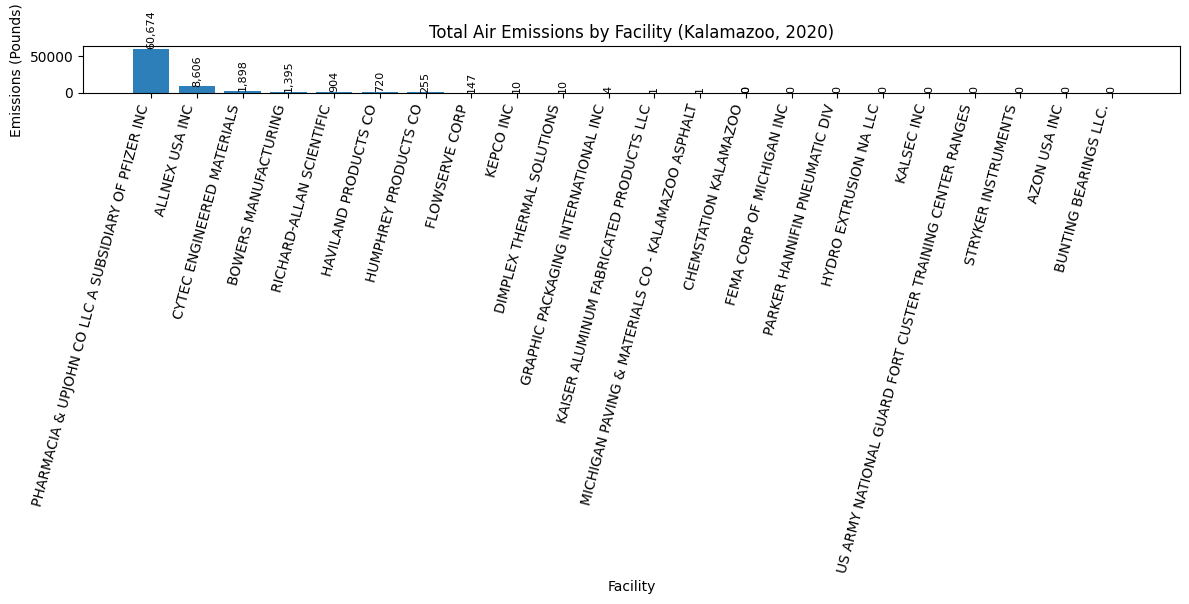

In [23]:

# Creating total air column
gdf['TOTAL_AIR'] = gdf['FUGITIVE_AIR'] + gdf['STACK_AIR']

# Sort
df_plot = gdf.sort_values(by='TOTAL_AIR', ascending=False)

plt.figure(figsize=(12,6))

bars = plt.bar(
    df_plot['FACILITY'],
    df_plot['TOTAL_AIR'],
    color='#2c7fb8'
)

# Adding values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',   # formatted number
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

plt.title('Total Air Emissions by Facility (Kalamazoo, 2020)')
plt.ylabel('Emissions (Pounds)')
plt.xlabel('Facility')
plt.xticks(rotation=75, ha='right')

plt.tight_layout()
plt.show()

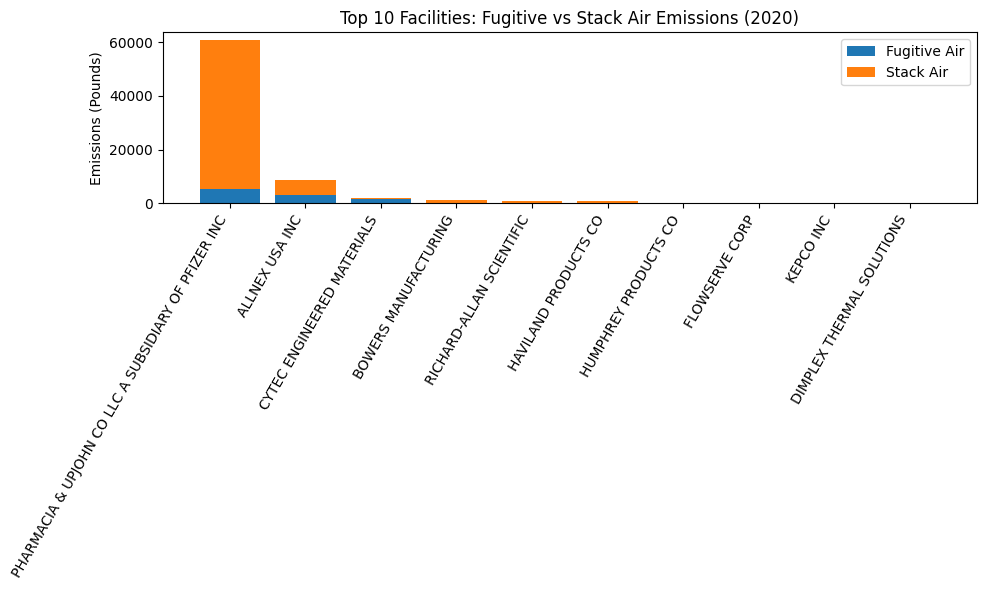

In [24]:
# The top 10 emitters (fugtive vs stack)
df_top10 = gdf.copy()
df_top10['TOTAL_AIR'] = df_top10['FUGITIVE_AIR'] + df_top10['STACK_AIR']
df_top10 = df_top10.sort_values(by='TOTAL_AIR', ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    df_top10['FACILITY'],
    df_top10['FUGITIVE_AIR'],
    label='Fugitive Air',
    color='#1f77b4'
)

plt.bar(
    df_top10['FACILITY'],
    df_top10['STACK_AIR'],
    bottom=df_top10['FUGITIVE_AIR'],
    label='Stack Air',
    color='#ff7f0e'
)

plt.title('Top 10 Facilities: Fugitive vs Stack Air Emissions (2020)')
plt.ylabel('Emissions (Pounds)')
plt.xticks(rotation=60, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:

# Creating emission classes
low = gdf[gdf['TOTAL_AIR'] <= 100]
medium = gdf[(gdf['TOTAL_AIR'] > 100) & (gdf['TOTAL_AIR'] <= 1000)]
high = gdf[(gdf['TOTAL_AIR'] > 1000) & (gdf['TOTAL_AIR'] <= 10000)]
very_high = gdf[gdf['TOTAL_AIR'] > 10000]

# Converting to GEE
low_ee = geemap.geopandas_to_ee(low)
medium_ee = geemap.geopandas_to_ee(medium)
high_ee = geemap.geopandas_to_ee(high)
very_high_ee = geemap.geopandas_to_ee(very_high)

# Creating map
Map_emissions = geemap.Map(basemap='CartoDB.Positron')
Map_emissions.centerObject(kalamazoo, 10)

# County boundary
Map_emissions.addLayer(
    kalamazoo.style(**{
        'color': '#08306b',
        'fillColor': '00000000',
        'width': 3
    }),
    {},
    'Kalamazoo County Boundary'
)

# Adding facilities by emission class
Map_emissions.addLayer(
    low_ee.style(**{
        'color': '#ffffb2',
        'pointSize': 4
    }),
    {},
    'Low: ≤ 100 lbs'
)

Map_emissions.addLayer(
    medium_ee.style(**{
        'color': '#fecc5c',
        'pointSize': 6
    }),
    {},
    'Medium: 101–1,000 lbs'
)

Map_emissions.addLayer(
    high_ee.style(**{
        'color': '#fd8d3c',
        'pointSize': 8
    }),
    {},
    'High: 1,001–10,000 lbs'
)

Map_emissions.addLayer(
    very_high_ee.style(**{
        'color': '#e31a1c',
        'pointSize': 12
    }),
    {},
    'Very High: > 10,000 lbs'
)

Map_emissions

Map(center=[42.245373214188064, -85.53118107546229], controls=(WidgetControl(options=['position', 'transparent…

As shown in the map above, TRI facilities have diffirent amount of air emissions (Fugitive + Stack Air). If a 2km buffer zone is being considered around each TRI facilties, that would give us a wrong count of people being exposed since some of the facilites does not have air emission at all. So a continuous emission-weighted buffers should be generated for TRI facilities with reported air emissions. For this analysis, I have considered buffer distances ranged from 500 m to 2,000 m and are scaled using total air emissions. This approach avoids treating all TRI facilities equally and gives greater spatial influence to facilities reporting higher airborne releases.

In [26]:
# removveing facilities with zero air emissions
gdf['TOTAL_AIR'] = gdf['FUGITIVE_AIR'] + gdf['STACK_AIR']

gdf_air = gdf[gdf['TOTAL_AIR'] > 0].copy()

gdf_air[['FACILITY', 'TOTAL_AIR']].sort_values(
    by='TOTAL_AIR',
    ascending=False
)

,FACILITY,TOTAL_AIR
0,PHARMACIA & UPJOHN CO LLC A SUBSIDIARY OF PFIZ...,60674.000
7,ALLNEX USA INC,8606.400
10,CYTEC ENGINEERED MATERIALS,1898.000
9,BOWERS MANUFACTURING,1395.468
3,RICHARD-ALLAN SCIENTIFIC,904.210
1,HAVILAND PRODUCTS CO,720.200
8,HUMPHREY PRODUCTS CO,255.000
17,FLOWSERVE CORP,147.110
4,DIMPLEX THERMAL SOLUTIONS,10.000
11,KEPCO INC,10.000


In [27]:
import numpy as np

# air-emitting facilities
gdf_air = gdf[gdf['TOTAL_AIR'] > 0].copy()

# PCS 
gdf_air_m = gdf_air.to_crs(epsg=32616).copy()


# log transforming to prevents Pfizer from becoming unrealistically huge
gdf_air_m['LOG_AIR'] = np.log1p(gdf_air_m['TOTAL_AIR'])

# Buffer Scale 500 m and 4000 m
min_buffer = 500
max_buffer = 2000

gdf_air_m['BUFFER_M'] = (
    min_buffer +
    (
        (gdf_air_m['LOG_AIR'] - gdf_air_m['LOG_AIR'].min()) /
        (gdf_air_m['LOG_AIR'].max() - gdf_air_m['LOG_AIR'].min())
    ) * (max_buffer - min_buffer)
)

# Creating buffer geometry
gdf_air_m['buffer'] = gdf_air_m.geometry.buffer(gdf_air_m['BUFFER_M'])

In [30]:
# Converting buffer back to WGS84 for GEE
gdf_air_buffer = gdf_air_m.set_geometry('buffer')
gdf_air_buffer = gdf_air_buffer.drop(columns='geometry')
gdf_air_buffer = gdf_air_buffer.rename(columns={'buffer': 'geometry'})
gdf_air_buffer = gdf_air_buffer.set_geometry('geometry')
gdf_air_buffer = gdf_air_buffer.to_crs(epsg=4326)

buffer_air_ee = geemap.geopandas_to_ee(gdf_air_buffer)

In [31]:
# Converting TRI air points to GEE
gdf_air_points = gdf_air.copy()

if 'buffer' in gdf_air_points.columns:
    gdf_air_points = gdf_air_points.drop(columns='buffer')

gdf_air_points = gdf_air_points.to_crs(epsg=4326)

tri_air_ee = geemap.geopandas_to_ee(gdf_air_points)

# Create map
Map_weighted_buffer = geemap.Map(basemap='CartoDB.Positron')
Map_weighted_buffer.centerObject(kalamazoo, 10)

# Population layer
Map_weighted_buffer.addLayer(
    pop_kzoo,
    pop_vis,
    'WorldPop Population 2020'
)

# Continuous emission-weighted buffers
Map_weighted_buffer.addLayer(
    buffer_air_ee.style(**{
        'color': '#d7301f',
        'fillColor': 'd7301f22',
        'width': 1
    }),
    {},
    'Emission-weighted TRI Buffers'
)

# TRI air-emitting facilities
Map_weighted_buffer.addLayer(
    tri_air_ee.style(**{
        'color': 'black',
        'pointSize': 4,
        'width': 1
    }),
    {},
    'TRI Facilities with Air Emissions'
)

# Kalamazoo County boundary
Map_weighted_buffer.addLayer(
    kalamazoo.style(**{
        'color': '#08306b',
        'fillColor': '00000000',
        'width': 3
    }),
    {},
    'Kalamazoo County Boundary'
)

Map_weighted_buffer

Map(center=[42.245373214188064, -85.53118107546229], controls=(WidgetControl(options=['position', 'transparent…

In [33]:


# Population inside emission-weighted buffers
stats = pop_kzoo.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=buffer_air_ee.geometry(),
    scale=100,
    maxPixels=1e13
)
exposed_population = stats.getInfo()

# extracting population value
exposed_pop = exposed_population['population']
print(f'Exposed Population: {exposed_pop:,.0f}')

Exposed Population: 17,280


In [34]:
# calculating total population in Kalamazoo County for context

total_stats = pop_kzoo.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=kalamazoo.geometry(),
    scale=100,
    maxPixels=1e13
)

total_population = total_stats.getInfo()

total_pop = total_population['population']
print(f'Total Population: {total_pop:,.0f}')

Total Population: 225,640


In [35]:
# Percent of population potentially exposed

percent_exposed = (exposed_pop / total_pop) * 100

print(f'Percent of population potentially exposed: {percent_exposed:.2f}%')

Percent of population potentially exposed: 7.66%


### 6.1.1 Result

All TRI facilities does not have airborne emissions in Kalamazoo county. For the year 2020, 13 out of 22 facilities has at least 1 pound or more airborne emission. Pfizer reported the highest amount of fugitive and stack air for the year 2020. Approximately 7.66 % of the population in Kalamazoo County resides within emission-weighted buffer zones of TRI facilities, indicating potential exposure to airborne industrial emissions.

### 6.2 Land Cover within Exposure Zones

In [36]:
# Extracting land cover values within buffers

lc_stats = worldcover_kzoo.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=buffer_air_ee.geometry(),
    scale=10,
    maxPixels=1e13
)

print(lc_stats.getInfo())

{'Map': {'10': 262174.51372549025, '20': 2, '30': 138819.48235294115, '40': 40164.72156862746, '50': 132044.0862745098, '60': 34281.7568627451, '80': 8773.8, '90': 3501.0745098039215}}


In [37]:
lc_dict = lc_stats.getInfo()['Map']

import pandas as pd

lc_df = pd.DataFrame(
    list(lc_dict.items()),
    columns=['LC_Code', 'Area']
)

lc_df['LC_Code'] = lc_df['LC_Code'].astype(int)

# Map labels
lc_labels = {
    10: 'Trees',
    20: 'Shrubland',
    30: 'Grassland',
    40: 'Cropland',
    50: 'Built-up',
    60: 'Bare',
    80: 'Water',
    90: 'Wetlands'
}

lc_df['Land_Cover'] = lc_df['LC_Code'].map(lc_labels)

lc_df = lc_df.sort_values(by='Area', ascending=False)

lc_df

,LC_Code,Area,Land_Cover
0,10,262174.513725,Trees
2,30,138819.482353,Grassland
4,50,132044.086275,Built-up
3,40,40164.721569,Cropland
5,60,34281.756863,Bare
6,80,8773.800000,Water
7,90,3501.074510,Wetlands
1,20,2.000000,Shrubland


In [38]:
lc_df['Percent'] = (lc_df['Area'] / lc_df['Area'].sum()) * 100

lc_df

,LC_Code,Area,Land_Cover,Percent
0,10,262174.513725,Trees,42.302489
2,30,138819.482353,Grassland,22.398858
4,50,132044.086275,Built-up,21.305631
3,40,40164.721569,Cropland,6.480675
5,60,34281.756863,Bare,5.531444
6,80,8773.800000,Water,1.415674
7,90,3501.074510,Wetlands,0.564907
1,20,2.000000,Shrubland,0.000323


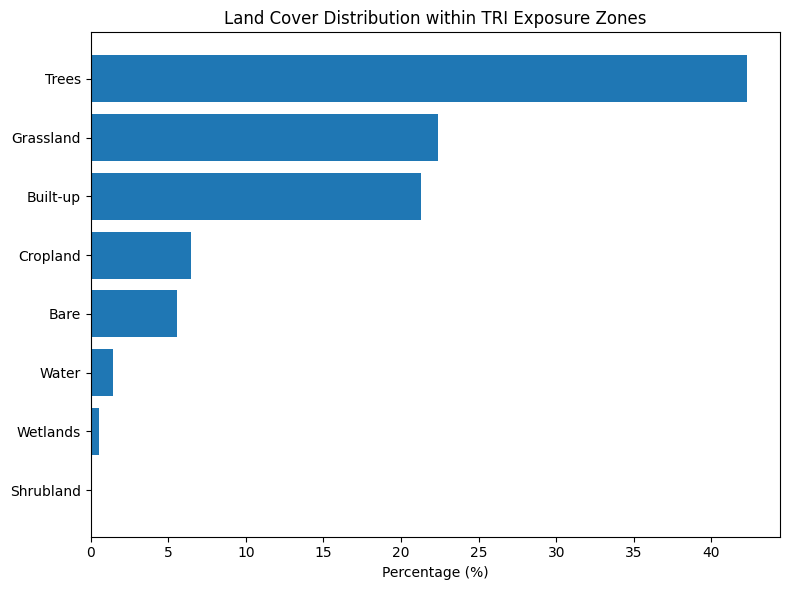

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(lc_df['Land_Cover'], lc_df['Percent'])
plt.xlabel('Percentage (%)')
plt.title('Land Cover Distribution within TRI Exposure Zones')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### 6.2.1 Comprision Analysis of the landcover 

In [40]:
import duckdb

con = duckdb.connect('../data/processed/kalamazoo_risk.duckdb')

In [41]:
# Land cover for entire Kalamazoo County
lc_total = worldcover_kzoo.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=kalamazoo.geometry(),
    scale=10,
    maxPixels=1e13
)

lc_total_dict = lc_total.getInfo()['Map']

lc_total_df = pd.DataFrame(
    list(lc_total_dict.items()),
    columns=['LC_Code', 'Area_Total']
)

lc_total_df['LC_Code'] = lc_total_df['LC_Code'].astype(int)
lc_total_df['Land_Cover'] = lc_total_df['LC_Code'].map(lc_labels)

lc_total_df['Percent_Total'] = (
    lc_total_df['Area_Total'] / lc_total_df['Area_Total'].sum()
) * 100

lc_total_df

,LC_Code,Area_Total,Land_Cover,Percent_Total
0,10,9.940768e+06,Trees,48.929611
1,20,3.000000e+00,Shrubland,0.000015
2,30,3.274510e+06,Grassland,16.117520
3,40,5.315198e+06,Cropland,26.162020
4,50,8.619672e+05,Built-up,4.242702
5,60,2.595823e+05,Bare,1.277694
6,80,5.166721e+05,Water,2.543120
7,90,1.477651e+05,Wetlands,0.727317


In [42]:
comparison = lc_df.merge(
    lc_total_df[['LC_Code', 'Percent_Total']],
    on='LC_Code',
    how='left'
)

comparison.rename(columns={
    'Percent': 'Percent_Buffer'
}, inplace=True)

comparison['Difference'] = (
    comparison['Percent_Buffer'] - comparison['Percent_Total']
)

con.register('landcover_comparison', comparison)

con.sql("""
    SELECT Land_Cover, Percent_Buffer, Percent_Total, Difference
    FROM landcover_comparison
    ORDER BY Difference DESC
""").df()

,Land_Cover,Percent_Buffer,Percent_Total,Difference
0,Built-up,21.305631,4.242702,17.062929
1,Grassland,22.398858,16.117520,6.281337
2,Bare,5.531444,1.277694,4.253750
3,Shrubland,0.000323,0.000015,0.000308
4,Wetlands,0.564907,0.727317,-0.162410
5,Water,1.415674,2.543120,-1.127446
6,Trees,42.302489,48.929611,-6.627122
7,Cropland,6.480675,26.162020,-19.681346


### 6.2.2 Results

The land cover analysis within emission-weighted TRI buffer zones indicates that exposure is distributed across multiple landscape types. The table shows built-up land is substantially overrepresented within emission-weighted TRI exposure zones compared with Kalamazoo County overall. Built-up areas make up 21.3% of the buffer zones but only 4.2% of the county, means that potential airborne industrial exposure is concentrated near developed and populated areas. In contrast, cropland is underrepresented in exposure zones, indicating that TRI-related air-emission influence is more concentrated around urban-industrial corridors than the county’s broader agricultural landscape.

## 6.3 Road Network vs Weighted TRI facilities Buffer Analysis

Here I want to demonstrate Roads intersecting emission-weighted TRI exposure zones to represent potential commuter exposure corridors. This analysis highlights where transportation routes overlap with areas of potential airborne industrial emission influence.

In [43]:
# Intersection of the road network with emission-weighted TRI exposure zones
roads_in_tri_zones = roads_ee.filterBounds(buffer_air_ee.geometry())

# creating map to visualize roads intersecting TRI exposure zones

Map_road_exposure = geemap.Map(basemap='CartoDB.Positron')
Map_road_exposure.centerObject(kalamazoo, 10)

# Population background
Map_road_exposure.addLayer(
    pop_kzoo,
    pop_vis,
    'WorldPop Population 2020'
)

# TRI weighted buffers
Map_road_exposure.addLayer(
    buffer_air_ee.style(**{
        'color': '#d7301f',
        'fillColor': 'd7301f22',
        'width': 1
    }),
    {},
    'TRI Exposure Zones'
)

# All major roads
Map_road_exposure.addLayer(
    roads_ee.style(**{
        'color': '#808080',
        'width': 1
    }),
    {},
    'Major Roads'
)

# Roads intersecting exposure zones
Map_road_exposure.addLayer(
    roads_in_tri_zones.style(**{
        'color': '#7b3294',
        'width': 3
    }),
    {},
    'Roads Intersecting TRI Exposure Zones'
)

# TRI facilities
Map_road_exposure.addLayer(
    tri_air_ee.style(**{
        'color': 'black',
        'pointSize': 4
    }),
    {},
    'TRI Facilities'
)

# County boundary
Map_road_exposure.addLayer(
    kalamazoo.style(**{
        'color': '#08306b',
        'fillColor': '00000000',
        'width': 3
    }),
    {},
    'Kalamazoo County Boundary'
)

Map_road_exposure

Map(center=[42.24537321418802, -85.53118107546234], controls=(WidgetControl(options=['position', 'transparent_…

In [44]:
# Quantifying how many road segments intersect TRI exposure zones
exposed_road_segments = roads_in_tri_zones.size().getInfo()
total_road_segments = roads_ee.size().getInfo()

print(f'Road segments intersecting TRI exposure zones: {exposed_road_segments}')
print(f'Total road segments: {total_road_segments}')
print(f'Percent of road segments intersecting TRI zones: {(exposed_road_segments / total_road_segments) * 100:.2f}%')

Road segments intersecting TRI exposure zones: 176
Total road segments: 1913
Percent of road segments intersecting TRI zones: 9.20%


### 6.3.1 Results

Approximately 9.2% of road segments in Kalamazoo County intersect emission-weighted TRI exposure zones. This means that a portion of daily commuters may experience repeated exposure to airborne industrial emissions while traveling through these corridors.

## 7. Limitations

- **TRI data are self-reported:** The Toxic Release Inventory is reported by facilities, so emission values may contain reporting uncertainty or inconsistencies.

- **Air emissions are aggregated annually:** The analysis uses total annual fugitive and stack air emissions for 2020. It does not identify the exact timing, duration, or seasonality of emissions.

- **Chemical toxicity is not weighted:** Different chemicals have different levels of toxicity and health impact, but this project treats all airborne emissions as a general industrial air pollution indicator.

- **Buffer zones simplify real exposure:** The emission-weighted buffers estimate potential exposure areas, but they do not model wind direction, atmospheric dispersion, topography, weather, or chemical transport.

- **Population exposure is static:** WorldPop represents residential population distribution, but it does not capture where people travel during the day for work, school, shopping, or commuting.

- **Road exposure does not measure traffic volume:** The road analysis identifies segments intersecting exposure zones, but it does not include traffic counts, travel time, congestion, or number of commuters using each road.

- **Land cover analysis provides context, not direct exposure:** ESA WorldCover helps describe the landscape within exposure zones, but land cover alone does not measure human exposure or health risk.

- **Spatial resolution and boundary effects may influence results:** Population and land cover estimates may vary depending on raster resolution, buffer size, and how exposure zones intersect raster cells.

## 8. Future Work

### 8.1 Model Improvements

- Incorporate atmospheric dispersion models to better represent the transport and spread of airborne pollutants  
- Include temporal analysis to account for seasonal and time-specific emission patterns  
- Integrate additional environmental indicators such as water and soil contamination  
- Extend the analysis to a formal environmental justice framework using demographic and socioeconomic data  


### 8.2 Toward Spatiotemporal Exposure Modeling

The current analysis relies on static population data derived from census-based sources (WorldPop), which represent spatial population distribution but do not account for human mobility throughout the day. As a result, exposure estimates assume that individuals remain at fixed locations, which may lead to over- or under-estimation of actual exposure.

In reality, environmental exposure is inherently **spatiotemporal**, depending not only on where people live but also on where they travel and how long they remain within areas of elevated risk. Future improvements could incorporate traffic data and temporally resolved emission records, allowing for more precise estimation of exposure during peak commuting periods or specific emission events.


### 8.3 Integration of Human Mobility Data

A more advanced extension of this approach would involve the integration of anonymized human mobility data, such as aggregated mobile device location data. These datasets could provide insight into population presence within exposure zones at different times of the day, enabling a transition from static population counts to **dynamic exposure modeling**.

However, access to such data is often limited due to privacy, ethical, and regulatory considerations, and must be handled with appropriate safeguards and aggregation methods.


### 8.4 Wearable Device Data and Individual Exposure

An additional perspective explored in this project is the use of personal GPS data collected from wearable devices. For example, I have been collecting location data using a Garmin watch, which records geographic coordinates at approximately 15-minute intervals since January 2026.

This dataset provides an opportunity to evaluate **individual-level exposure** by calculating the duration of time spent within TRI facility buffer zones. Unlike census-based datasets, this approach captures real-world movement patterns and time-dependent exposure, offering a more detailed understanding of how environmental risk is experienced in daily life.

While this dataset is not representative of the broader population and cannot be generalized, it serves as a valuable **proof-of-concept for activity-based exposure modeling**.


### 8.5 Future Direction and Implications

If similar data were available at scale (e.g., through anonymized and aggregated mobile or wearable datasets), it would be possible to estimate not only how many people are exposed, but also their level of exposure based on duration and frequency of contact with risk zones.

Overall, incorporating mobility patterns and temporal dynamics would significantly improve the accuracy of environmental risk assessments and provide a more realistic representation of population exposure. These approaches would be particularly valuable for advancing environmental justice analyses, where understanding who is exposed, when, and for how long is critical for informed decision-making.